First, we want to read in the data and ask AI to assist us in getting a visual representation of the existing data.

In [1]:
import pandas as pd

In [2]:
big_nss= pd.read_csv(r"C:\Users\Owner\Documents\NSS\PYTHON\Projects\big-nss-Leslygcruz\big_nss.csv")

C:\Users\Owner\AppData\Local\Temp\ipykernel_10780\1326881047.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  big_nss= pd.read_csv(r"C:\Users\Owner\Documents\NSS\PYTHON\Projects\big-nss-Leslygcruz\big_nss.csv")


In [3]:
# EquipmentID was read as a mix of int and str (pandas infers dtype per chunk),
# which silently splits a single truck into two different groups (e.g. 2015 vs '2015').
# Cast to a single consistent type so per-truck grouping is correct downstream.
big_nss['EquipmentID'] = big_nss['EquipmentID'].astype(str)
print('Unique EquipmentIDs:', big_nss['EquipmentID'].nunique())

Unique EquipmentIDs: 1122


Read in 'big_nss.csv' and save it as a dataframe named big_nss. First, create a visualization to look at the 5 measurement columns to see how they compare when there is a derate vs not. Ask Claude to help you write code that will compare 5 columns of numeric data for trucks experiencing a derate compared to those that aren't.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

measurement_cols = [
    'EngineOilPressure',
    'EngineOilTemperature',
    'DistanceLtd',
    'FuelLtd',
    'EngineTimeLtd',
]

print(big_nss['Derate'].value_counts(dropna=False))
print()
print(big_nss[measurement_cols].isna().sum())

Derate
False    1186140
True        1195
Name: count, dtype: int64

EngineOilPressure       601091
EngineOilTemperature    603423
DistanceLtd             601516
FuelLtd                 602140
EngineTimeLtd           605969
dtype: int64


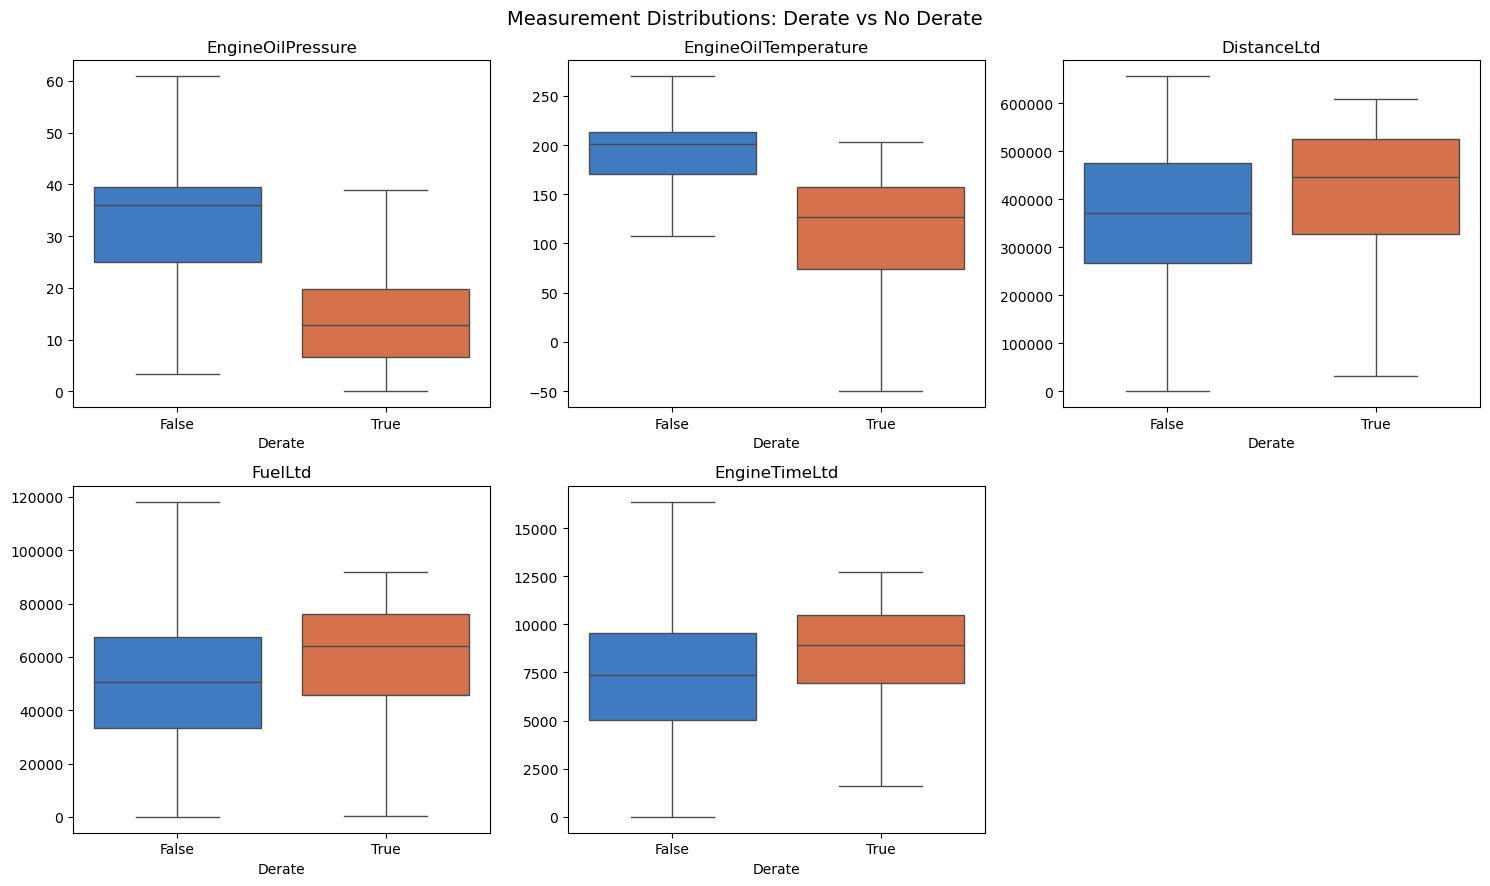

In [5]:
# Two-category palette: blue = not in derate, orange = in derate
derate_palette = {False: '#2a78d6', True: '#eb6834'}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, col in zip(axes, measurement_cols):
    sns.boxplot(
        data=big_nss,
        x='Derate',
        y=col,
        hue='Derate',
        palette=derate_palette,
        legend=False,
        showfliers=False,
        ax=ax,
    )
    ax.set_title(col)
    ax.set_xlabel('Derate')
    ax.set_ylabel('')

# 6th subplot is unused (only 5 measurement columns)
axes[-1].axis('off')

fig.suptitle('Measurement Distributions: Derate vs No Derate', fontsize=14)
fig.tight_layout()
plt.show()

In [6]:
# Numeric backup for what the boxplots show visually
big_nss.groupby('Derate')[measurement_cols].median()

,EngineOilPressure,EngineOilTemperature,DistanceLtd,FuelLtd,EngineTimeLtd
Derate,,,,,
False,35.96000,200.918700,372713.15,50583.532431,7376.45
True,12.75904,127.246825,446059.60,63902.579916,8946.05


## Step 2 — Drop rows with no measurement data at all

Drop any row where **both** `EngineOil` columns (`EngineOilPressure`, `EngineOilTemperature`) **and** all 3 `Ltd` columns (`DistanceLtd`, `FuelLtd`, `EngineTimeLtd`) are null — i.e. the row carries no measurement information whatsoever.

In [7]:
engine_oil_cols = ['EngineOilPressure', 'EngineOilTemperature']
ltd_cols = ['DistanceLtd', 'FuelLtd', 'EngineTimeLtd']

rows_all_null = big_nss[engine_oil_cols].isna().all(axis=1) & big_nss[ltd_cols].isna().all(axis=1)
print('Rows to drop:', rows_all_null.sum())
print('Rows before:', len(big_nss))

big_nss = big_nss.loc[~rows_all_null].reset_index(drop=True)

print('Rows after:', len(big_nss))

Rows to drop: 599700
Rows before: 1187335
Rows after: 587635


Some trucks are missing an entire `Ltd` column (every row for that `EquipmentID` is NaN in that column). Drop all `EquipmentID`s that have 100% NaN in at least 2 of the 3 `Ltd` columns.

In [8]:
# For each EquipmentID, is each Ltd column *entirely* NaN across all of that truck's rows?
ltd_all_null_by_equipment = big_nss.groupby('EquipmentID')[ltd_cols].apply(lambda g: g.isna().all())

# EquipmentIDs where at least 2 of the 3 Ltd columns are entirely NaN
equipment_to_drop = ltd_all_null_by_equipment[ltd_all_null_by_equipment.sum(axis=1) >= 2].index

print('EquipmentIDs to drop:', len(equipment_to_drop))
print('Rows before:', len(big_nss))

big_nss = big_nss.loc[~big_nss['EquipmentID'].isin(equipment_to_drop)].reset_index(drop=True)

print('Rows after:', len(big_nss))

EquipmentIDs to drop: 4
Rows before: 587635
Rows after: 587630


Next, for rows that have **at least 1** non-null `Ltd` value but are missing the others, predict the missing ones with linear regression:
- **Per-truck first**: fit a regression using only that `EquipmentID`'s own rows, since each truck has its own fairly stable fuel economy / engine-hours-per-mile.
- **Global fallback**: if a truck doesn't have enough of its own complete pairs (fewer than 5) to fit a stable model, fall back to a regression fit across the whole fleet.
- **Multi-predictor when available**: if a row has 2 of the 3 Ltd values present, use both as predictors for the missing one; if only 1 is present, use that one.

In [9]:
from sklearn.linear_model import LinearRegression

MIN_TRUCK_ROWS = 5  # minimum complete pairs a truck needs to get its own regression


def fill_ltd_column(df, target, predictors):
    """Fill nulls in `target` using `predictors`, per-truck first, global fallback."""
    predictors_present = df[predictors].notna().all(axis=1)
    to_fill = df[target].isna() & predictors_present
    if to_fill.sum() == 0:
        return 0

    train_mask = df[target].notna() & predictors_present
    global_model = LinearRegression().fit(df.loc[train_mask, predictors], df.loc[train_mask, target])

    predictions = pd.Series(index=df.index, dtype=float)
    for equip_id, idx in df.loc[to_fill].groupby('EquipmentID').groups.items():
        truck_train_mask = train_mask & (df['EquipmentID'] == equip_id)
        if truck_train_mask.sum() >= MIN_TRUCK_ROWS:
            model = LinearRegression().fit(df.loc[truck_train_mask, predictors], df.loc[truck_train_mask, target])
        else:
            model = global_model
        predictions.loc[idx] = model.predict(df.loc[idx, predictors])

    df.loc[to_fill, target] = predictions.loc[to_fill]
    return int(to_fill.sum())


for target in ltd_cols:
    others = [c for c in ltd_cols if c != target]
    # both-predictor combo first (more information), then each single-predictor combo
    for predictors in ([others, [others[0]], [others[1]]]):
        n_filled = fill_ltd_column(big_nss, target, predictors)
        print(f'{target} filled using {predictors}: {n_filled}')

print()
print(big_nss[ltd_cols].isna().sum())

DistanceLtd filled using ['FuelLtd', 'EngineTimeLtd']: 1266


DistanceLtd filled using ['FuelLtd']: 178


DistanceLtd filled using ['EngineTimeLtd']: 81


FuelLtd filled using ['DistanceLtd', 'EngineTimeLtd']: 1406


FuelLtd filled using ['DistanceLtd']: 745
FuelLtd filled using ['EngineTimeLtd']: 0


EngineTimeLtd filled using ['DistanceLtd', 'FuelLtd']: 5978
EngineTimeLtd filled using ['DistanceLtd']: 0
EngineTimeLtd filled using ['FuelLtd']: 0

DistanceLtd      286
FuelLtd          286
EngineTimeLtd    286
dtype: int64


For the remaining nulls (rows with **no** Ltd values at all), fill them by linear interpolation between the last known value and the next known value for the same `EquipmentID`, stepping evenly across the gap. `limit_area='inside'` means we only fill *between* two known points for that truck — not before its first reading or after its last.

In [10]:
# Sort within each truck by time so interpolation steps along the correct sequence
big_nss = big_nss.sort_values(['EquipmentID', 'EventTimeStamp'], kind='stable')

print('Nulls before interpolation:')
print(big_nss[ltd_cols].isna().sum())

for col in ltd_cols:
    big_nss[col] = big_nss.groupby('EquipmentID')[col].transform(
        lambda s: s.interpolate(method='linear', limit_area='inside')
    )

# Restore original row order
big_nss = big_nss.sort_index().reset_index(drop=True)

print()
print('Nulls after interpolation:')
print(big_nss[ltd_cols].isna().sum())

Nulls before interpolation:
DistanceLtd      286
FuelLtd          286
EngineTimeLtd    286
dtype: int64



Nulls after interpolation:
DistanceLtd      6
FuelLtd          6
EngineTimeLtd    6
dtype: int64


## Fill the EngineOil columns

`EngineOilPressure` and `EngineOilTemperature` are instantaneous readings, not cumulative totals like the Ltd columns, so their relationship to the Ltd columns is weaker and likely non-linear (a slow wear trend buried in operational noise). We use a **Random Forest Regressor** instead of linear regression here, trained globally with `EquipmentID` included as a feature (so a single model can still learn each truck's own baseline via its splits, without fitting a separate unstable model per truck on a noisy signal):

- **Both EngineOil columns missing**: predict each from the 3 Ltd columns + `EquipmentID`.
- **Only one EngineOil column missing**: predict it from the 3 Ltd columns + `EquipmentID` + the other, known EngineOil value.

In [11]:
from sklearn.ensemble import RandomForestRegressor

# Encode EquipmentID as an integer so tree splits can use it
big_nss['EquipmentID_code'] = big_nss['EquipmentID'].astype('category').cat.codes

RF_PARAMS = dict(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
base_features = ltd_cols + ['EquipmentID_code']

# Capture original nullity up front so later fills never leak into earlier training data
pressure_known = big_nss['EngineOilPressure'].notna()
temp_known = big_nss['EngineOilTemperature'].notna()
ltd_and_id_present = big_nss[base_features].notna().all(axis=1)

both_missing = ~pressure_known & ~temp_known & ltd_and_id_present
only_pressure_missing = ~pressure_known & temp_known & ltd_and_id_present
only_temp_missing = ~temp_known & pressure_known & ltd_and_id_present


def fit_and_predict(train_mask, predict_mask, features, target):
    if predict_mask.sum() == 0:
        return 0
    model = RandomForestRegressor(**RF_PARAMS).fit(
        big_nss.loc[train_mask, features], big_nss.loc[train_mask, target]
    )
    big_nss.loc[predict_mask, target] = model.predict(big_nss.loc[predict_mask, features])
    return int(predict_mask.sum())


# Case 1: both EngineOil columns missing -> predict each from Ltd columns + EquipmentID only
for target, target_known in [('EngineOilPressure', pressure_known), ('EngineOilTemperature', temp_known)]:
    train_mask = target_known & ltd_and_id_present
    n = fit_and_predict(train_mask, both_missing, base_features, target)
    print(f'{target} filled (both missing): {n}')

# Case 2: only one EngineOil column missing -> predict using Ltd columns + EquipmentID + the known oil value
oil_pairs = [
    ('EngineOilPressure', pressure_known, 'EngineOilTemperature', temp_known, only_pressure_missing),
    ('EngineOilTemperature', temp_known, 'EngineOilPressure', pressure_known, only_temp_missing),
]
for target, target_known, other, other_known, predict_mask in oil_pairs:
    features = base_features + [other]
    train_mask = target_known & other_known & ltd_and_id_present
    n = fit_and_predict(train_mask, predict_mask, features, target)
    print(f'{target} filled (one missing, using {other}): {n}')

print()
print(big_nss[engine_oil_cols].isna().sum())

EngineOilPressure filled (both missing): 1013


EngineOilTemperature filled (both missing): 1013


EngineOilPressure filled (one missing, using EngineOilTemperature): 378


EngineOilTemperature filled (one missing, using EngineOilPressure): 2707

EngineOilPressure       0
EngineOilTemperature    3
dtype: int64
